In [4]:
import kagglehub
tonygordonjr_spotify_dataset_2023_path = kagglehub.dataset_download('tonygordonjr/spotify-dataset-2023')
print('Data source import complete.')

Using Colab cache for faster access to the 'spotify-dataset-2023' dataset.
Data source import complete.


In [5]:
import pandas as pd
path = r'/kaggle/input/spotify-dataset-2023/spotify_data_12_20_2023.csv'
songs = pd.read_csv(path, low_memory=False)
songs.columns

Index(['album_id', 'album_name', 'album_popularity', 'album_type', 'artists',
       'artist_0', 'artist_1', 'artist_2', 'artist_3', 'artist_4', 'artist_id',
       'duration_sec', 'label', 'release_date', 'total_tracks', 'track_id',
       'track_name', 'track_number', 'artist_genres', 'artist_popularity',
       'followers', 'name', 'genre_0', 'genre_1', 'genre_2', 'genre_3',
       'genre_4', 'acousticness', 'analysis_url', 'danceability',
       'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness',
       'loudness', 'mode', 'speechiness', 'tempo', 'time_signature',
       'track_href', 'type', 'uri', 'valence', 'explicit', 'track_popularity',
       'release_year', 'release_month', 'rn'],
      dtype='object')

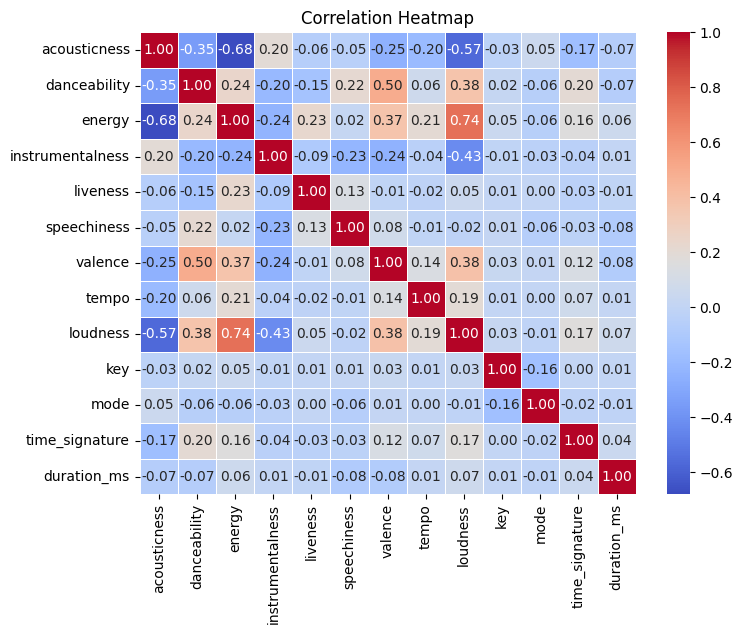

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = songs[['acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'speechiness', 'valence', 'tempo', 'loudness',
       'key', 'mode', 'time_signature', 'duration_ms',
       'genre_0', 'genre_1', 'genre_2', 'genre_3']]

matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

### Data preprocessing

In [8]:
import gc
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

numeric_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'speechiness', 'valence', 'tempo', 'loudness', 'duration_ms'
]
categorical_features = ['genre_0', 'genre_1', 'genre_2', 'genre_3']

df = df.dropna(subset='genre_0')
print(f"After cleaning: {len(df):,} tracks")

for f in numeric_features:
    df[f] = df[f].fillna(df[f].median())
    df[f] = df[f].clip(df[f].quantile(0.01), df[f].quantile(0.99))

scaler = StandardScaler()
X_num = scaler.fit_transform(df[numeric_features]).astype('float32')
print(f"Numeric features: {X_num.shape}")

genre_encoders = {}
X_genres = np.zeros((len(df), len(categorical_features)), dtype=np.int64)

for i, col in enumerate(categorical_features):
    le = LabelEncoder()

    values = df[col].fillna('unknown').values
    encoded = le.fit_transform(values) + 1
    X_genres[:, i] = encoded
    genre_encoders[col] = le
    print(f"{col}: {len(le.classes_):,} unique genres")

genre_vocab_size = X_genres.max() + 1
print(f"\nGenre vocab size: {genre_vocab_size:,}")
print(f"Numeric features: {X_num.shape[1]}")

input_num_dim = X_num.shape[1]   # 10

After cleaning: 209,863 tracks
Numeric features: (209863, 10)
genre_0: 3,008 unique genres
genre_1: 1,741 unique genres
genre_2: 956 unique genres
genre_3: 525 unique genres

Genre vocab size: 3,009
Numeric features: 10


### Dataset with tabular augmentations

In [ ]:
class SSLTabularDataset(Dataset):

    def __init__(self, X_num, X_genres, num_mask_prob=0.15,
                 genre_drop_prob=0.15, noise_std=0.2):
        self.X_num    = X_num
        self.X_genres = X_genres
        self.num_features   = X_num.shape[1]
        self.num_mask_prob  = num_mask_prob
        self.genre_drop_prob = genre_drop_prob
        self.noise_std      = noise_std

    def augment_num(self, x):
        x_aug = x.clone()
        x_aug += torch.randn_like(x_aug) * self.noise_std
        mask = torch.rand(x_aug.shape[0]) < self.num_mask_prob
        x_aug = x_aug.masked_fill(mask, 0.0)
        return x_aug

    def augment_genres(self, g):
        g_aug = g.clone()
        mask = torch.rand(g_aug.shape[0]) < self.genre_drop_prob
        g_aug = g_aug.masked_fill(mask, 0)
        return g_aug

    def __len__(self):
        return self.X_num.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X_num[idx].astype('float32'))
        g = torch.from_numpy(self.X_genres[idx])

        return (self.augment_num(x), self.augment_genres(g),
                self.augment_num(x), self.augment_genres(g))

n, n_feat = X_num.shape
X_num_f16 = np.empty((n, n_feat), dtype=np.float16)
CHUNK = 50_000
for start in range(0, n, CHUNK):
    end = min(start + CHUNK, n)
    X_num_f16[start:end] = X_num[start:end].astype(np.float16)
del X_num
gc.collect()
print(f"float16 RAM: {X_num_f16.nbytes / 1024**2:.1f} MB")

dataset = SSLTabularDataset(X_num_f16, X_genres)

loader = DataLoader(
    dataset,
    batch_size=4096,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
    drop_last=True,
    prefetch_factor=2
)

float16 RAM: 4.0 MB


### Model

In [ ]:
class Encoder(nn.Module):

    def __init__(self, num_dim, genre_vocab_size, genre_embed_dim=32,
                 latent_dim=128):
        super().__init__()

        self.genre_embedding = nn.Embedding(
            genre_vocab_size, genre_embed_dim, padding_idx=0
        )

        genre_flat_dim = genre_embed_dim * 4

        self.net = nn.Sequential(
            nn.Linear(num_dim + genre_flat_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, latent_dim),
        )

    def forward(self, x_num, x_genres):

        g_emb = self.genre_embedding(x_genres)
        g_emb = g_emb.view(g_emb.size(0), -1)

        x = torch.cat([x_num, g_emb], dim=1)
        z = self.net(x)
        return F.normalize(z, dim=1)


class ProjectionHead(nn.Module):
    def __init__(self, latent_dim=128, proj_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, proj_dim)
        )

    def forward(self, z):
        return F.normalize(self.net(z), dim=1)


encoder   = Encoder(input_num_dim, genre_vocab_size).to(device)
projector = ProjectionHead().to(device)

optimizer = optim.AdamW(
    list(encoder.parameters()) + list(projector.parameters()),
    lr=1.6e-3,
    weight_decay=1e-4
)

total_params = sum(p.numel() for p in encoder.parameters())
print(f"Encoder parameters: {total_params:,}")

Encoder parameters: 333,216


### SimCLR loss

In [ ]:
def nt_xent_loss(z1, z2, temperature=0.3):
    batch_size = z1.size(0)

    z = torch.cat([z1, z2], dim=0)
    sim = torch.matmul(z, z.T) / temperature

    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=device)
    sim.masked_fill_(mask, float('-inf'))

    labels = torch.arange(batch_size, device=device)
    labels = torch.cat([labels + batch_size, labels])

    return F.cross_entropy(sim, labels)

### Training loop

In [ ]:
import math

epochs = 100

def get_lr_lambda(epoch):
    warmup_epochs = 10
    if epoch < warmup_epochs:
        return epoch / warmup_epochs
    progress = (epoch - warmup_epochs) / (epochs - warmup_epochs)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda)

encoder   = torch.compile(encoder)
projector = torch.compile(projector)

use_amp = device.type == "cuda"
scaler  = torch.amp.GradScaler("cuda", enabled=use_amp)

encoder.train()
projector.train()

for epoch in range(epochs):
    total_loss = 0

    for x1_num, x1_genres, x2_num, x2_genres in loader:
        x1_num    = x1_num.to(device, non_blocking=use_amp)
        x1_genres = x1_genres.to(device, non_blocking=use_amp)
        x2_num    = x2_num.to(device, non_blocking=use_amp)
        x2_genres = x2_genres.to(device, non_blocking=use_amp)

        with torch.autocast(device_type=device.type,
                            dtype=torch.float16, enabled=use_amp):
            z1 = encoder(x1_num, x1_genres)
            z2 = encoder(x2_num, x2_genres)
            p1 = projector(z1)
            p2 = projector(z2)
            loss = nt_xent_loss(p1, p2)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(projector.parameters()),
            max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    scheduler.step()

    if epoch == epochs - 1 or (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch,
            'encoder_state_dict':   encoder._orig_mod.state_dict(),
            'projector_state_dict': projector._orig_mod.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'genre_encoders':       genre_encoders,
            'genre_vocab_size':     genre_vocab_size,
        }, f"checkpoint_epoch_{epoch}.pt")

    print(f"Epoch {epoch+1:>3}/{epochs}  Loss: {total_loss / len(loader):.4f}")

W0316 18:09:09.244000 11479 torch/_inductor/utils.py:1679] [1/0] Not enough SMs to use max_autotune_gemm mode


Epoch   1/100  Loss: 8.2479
Epoch   2/100  Loss: 7.1815
Epoch   3/100  Loss: 6.6504
Epoch   4/100  Loss: 6.5171
Epoch   5/100  Loss: 6.4465
Epoch   6/100  Loss: 6.4021
Epoch   7/100  Loss: 6.3675
Epoch   8/100  Loss: 6.3421
Epoch   9/100  Loss: 6.3185
Epoch  10/100  Loss: 6.2979
Epoch  11/100  Loss: 6.2841
Epoch  12/100  Loss: 6.2742
Epoch  13/100  Loss: 6.2595
Epoch  14/100  Loss: 6.2491
Epoch  15/100  Loss: 6.2411
Epoch  16/100  Loss: 6.2348
Epoch  17/100  Loss: 6.2226
Epoch  18/100  Loss: 6.2198
Epoch  19/100  Loss: 6.2140
Epoch  20/100  Loss: 6.2082
Epoch  21/100  Loss: 6.2025
Epoch  22/100  Loss: 6.1999
Epoch  23/100  Loss: 6.1951
Epoch  24/100  Loss: 6.1896
Epoch  25/100  Loss: 6.1848
Epoch  26/100  Loss: 6.1841
Epoch  27/100  Loss: 6.1791
Epoch  28/100  Loss: 6.1760
Epoch  29/100  Loss: 6.1732
Epoch  30/100  Loss: 6.1731
Epoch  31/100  Loss: 6.1673
Epoch  32/100  Loss: 6.1634
Epoch  33/100  Loss: 6.1644
Epoch  34/100  Loss: 6.1635
Epoch  35/100  Loss: 6.1591
Epoch  36/100  Loss: